This is to explore Long Short-Term Memory (LSTM) networks, a type of recurrent neural network (RNN), be use for stock price prediction

In [1]:
#
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

#import os
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error

import yfinance as yf

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Data source from yfinance as below
#   tentatively retreive 3 years stock data

company = "0005.HK"
df_HKstock = yf.download(company, start="2025-01-01", end="2026-01-01",
                    auto_adjust=True ).droplevel('Ticker', axis=1)
df_HKstock

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2025-01-02,69.046951,69.183770,68.089237,69.138168,15851617
2025-01-03,68.408485,69.092570,68.317275,68.682122,11755463
2025-01-06,68.910149,69.001359,68.545302,68.864540,12886461
2025-01-07,68.682121,69.229388,68.317275,68.864541,18577225
2025-01-08,69.274986,69.274986,68.180453,68.682118,18019505
...,...,...,...,...,...
2025-12-23,117.824440,117.920779,117.150052,117.439077,10892666
2025-12-24,119.365891,119.365891,119.365891,119.365891,0
2025-12-29,117.439079,119.173204,117.053716,119.173204,13132355


In [4]:
# Save copy to CSV
df_HKstock.to_csv('0005.HK260101.csv')

In [5]:
#
df_source = pd.read_csv("0005.HK260101.csv")
df_source

,Date,Close,High,Low,Open,Volume
0,2025-01-02,69.046951,69.183770,68.089237,69.138168,15851617
1,2025-01-03,68.408485,69.092570,68.317275,68.682122,11755463
2,2025-01-06,68.910149,69.001359,68.545302,68.864540,12886461
3,2025-01-07,68.682121,69.229388,68.317275,68.864541,18577225
4,2025-01-08,69.274986,69.274986,68.180453,68.682118,18019505
...,...,...,...,...,...,...
241,2025-12-23,117.824440,117.920779,117.150052,117.439077,10892666
242,2025-12-24,119.365891,119.365891,119.365891,119.365891,0
243,2025-12-29,117.439079,119.173204,117.053716,119.173204,13132355
244,2025-12-30,118.498825,118.787850,116.764693,116.764693,11747636


In [6]:
# Set Date
df_source["Date"] = pd.to_datetime(df_source["Date"], format="%Y-%m-%d")
df_source

,Date,Close,High,Low,Open,Volume
0,2025-01-02,69.046951,69.183770,68.089237,69.138168,15851617
1,2025-01-03,68.408485,69.092570,68.317275,68.682122,11755463
2,2025-01-06,68.910149,69.001359,68.545302,68.864540,12886461
3,2025-01-07,68.682121,69.229388,68.317275,68.864541,18577225
4,2025-01-08,69.274986,69.274986,68.180453,68.682118,18019505
...,...,...,...,...,...,...
241,2025-12-23,117.824440,117.920779,117.150052,117.439077,10892666
242,2025-12-24,119.365891,119.365891,119.365891,119.365891,0
243,2025-12-29,117.439079,119.173204,117.053716,119.173204,13132355
244,2025-12-30,118.498825,118.787850,116.764693,116.764693,11747636


In [7]:
df_source.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    246 non-null    datetime64[ns]
 1   Close   246 non-null    float64       
 2   High    246 non-null    float64       
 3   Low     246 non-null    float64       
 4   Open    246 non-null    float64       
 5   Volume  246 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 11.7 KB


In [8]:
# Set Date as index - time series data
df_source = df_source.set_index('Date', ) 
df_source.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 246 entries, 2025-01-02 to 2025-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   246 non-null    float64
 1   High    246 non-null    float64
 2   Low     246 non-null    float64
 3   Open    246 non-null    float64
 4   Volume  246 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.5 KB


In [9]:
df = df_source
df

,Close,High,Low,Open,Volume
Date,,,,,
2025-01-02,69.046951,69.183770,68.089237,69.138168,15851617
2025-01-03,68.408485,69.092570,68.317275,68.682122,11755463
2025-01-06,68.910149,69.001359,68.545302,68.864540,12886461
2025-01-07,68.682121,69.229388,68.317275,68.864541,18577225
2025-01-08,69.274986,69.274986,68.180453,68.682118,18019505
...,...,...,...,...,...
2025-12-23,117.824440,117.920779,117.150052,117.439077,10892666
2025-12-24,119.365891,119.365891,119.365891,119.365891,0
2025-12-29,117.439079,119.173204,117.053716,119.173204,13132355


In [10]:
# Data pre-processing
df.isnull().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [11]:
# This is preserve as for handling missing values, if applicable
df.bfill()

,Close,High,Low,Open,Volume
Date,,,,,
2025-01-02,69.046951,69.183770,68.089237,69.138168,15851617
2025-01-03,68.408485,69.092570,68.317275,68.682122,11755463
2025-01-06,68.910149,69.001359,68.545302,68.864540,12886461
2025-01-07,68.682121,69.229388,68.317275,68.864541,18577225
2025-01-08,69.274986,69.274986,68.180453,68.682118,18019505
...,...,...,...,...,...
2025-12-23,117.824440,117.920779,117.150052,117.439077,10892666
2025-12-24,119.365891,119.365891,119.365891,119.365891,0
2025-12-29,117.439079,119.173204,117.053716,119.173204,13132355


In [12]:
# Calculate moving averages and daily returns

df['20-day MA'] = df['Close'].rolling(window=20).mean()
df['50-day MA'] = df['Close'].rolling(window=50).mean()
df['Daily Return'] = df['Close'].pct_change()

In [13]:
# To check NaN
df[df.isna().values==True].drop_duplicates()

,Close,High,Low,Open,Volume,20-day MA,50-day MA,Daily Return
Date,,,,,,,,
2025-01-02,69.046951,69.183770,68.089237,69.138168,15851617,NaN,NaN,NaN
2025-01-03,68.408485,69.092570,68.317275,68.682122,11755463,NaN,NaN,-0.009247
2025-01-06,68.910149,69.001359,68.545302,68.864540,12886461,NaN,NaN,0.007333
2025-01-07,68.682121,69.229388,68.317275,68.864541,18577225,NaN,NaN,-0.003309
2025-01-08,69.274986,69.274986,68.180453,68.682118,18019505,NaN,NaN,0.008632
2025-01-09,68.955734,69.503001,68.955734,69.229371,12063607,NaN,NaN,-0.004608
2025-01-10,69.776657,69.867867,69.548629,69.776657,22361611,NaN,NaN,0.011905
2025-01-13,68.682121,69.411808,68.271666,69.320598,14415841,NaN,NaN,-0.015686
2025-01-14,69.274986,69.274986,68.773328,68.818930,12841705,NaN,NaN,0.008632


In [14]:
df = df.dropna()   # Drop all NaN
df

,Close,High,Low,Open,Volume,20-day MA,50-day MA,Daily Return
Date,,,,,,,,
2025-03-17,82.450745,83.062189,82.074471,82.074471,20789698,81.256425,75.818819,0.025746
2025-03-18,83.767700,83.955834,83.297359,83.297359,18279111,81.467997,76.113233,0.015973
2025-03-19,84.426170,84.661341,84.238037,84.661341,18366668,81.657766,76.433587,0.007861
2025-03-20,84.473221,85.084658,84.473221,84.661354,18680778,81.906894,76.744849,0.000557
2025-03-21,83.344391,83.814732,83.203287,83.297361,17088782,82.120104,77.038094,-0.013363
...,...,...,...,...,...,...,...,...
2025-12-23,117.824440,117.920779,117.150052,117.439077,10892666,109.548790,105.471436,0.008244
2025-12-24,119.365891,119.365891,119.365891,119.365891,0,110.333965,105.909447,0.013083
2025-12-29,117.439079,119.173204,117.053716,119.173204,13132355,110.955361,106.278315,-0.016142


In [25]:
# Configuration

# For ~ 80:20 Split
test_days = 40

# choose the number of days on which to base our predictions 
nb_days = 60

# Number of days into the future we want to predict
n_steps_out = 30

#
epochsMS=15 
batch_sizeMS = 32

In [16]:
# For normailized Data

# from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))  
scaled_data = scaler.fit_transform(df['Close'].values.reshape(-1,1))

In [17]:
# ADF Test : p-value < 0.05 for stationary data

#from statsmodels.tsa.stattools import adfuller

close_series = df['Close']
def check_stationarity(series):
    result = adfuller(series.dropna())  # Drop NaN values if any
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    if result[1] < 0.05:
        print("The series is stationary.")
    else:
        print("The series is not stationary.")

check_stationarity(close_series)

ADF Statistic: -0.5107349461070493
p-value: 0.8899045647048225
The series is not stationary.


# To transform time series stationary...
There are three major time series patterns: trend, seasonality, and cycles. Trend and cycles are usually combined into a single component, with a trend-cycle component, a seasonal component, and a remainder component (containing the rest of the time series).

To make time series stationary, the principle is to estimate trend and seasonality, and to remove those from the time series. Then to apply the forecasting technique (i.e here LSTM), the final step being to convert the forcasted values into the original scale by adding the estimated trend and seasonality.

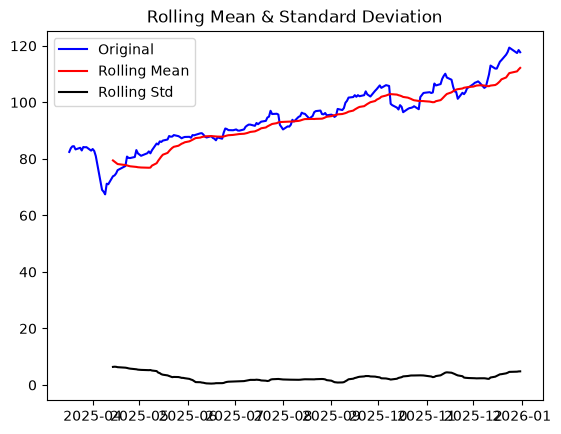

Results of Dickey-Fuller Test:
Test Statistic                  -0.510735
p-value                          0.889905
#Lags Used                       2.000000
Number of Observations Used    194.000000
Critical Value (1%)             -3.464515
Critical Value (5%)             -2.876556
Critical Value (10%)            -2.574775
dtype: float64


In [18]:
#... The following cells are use for model(s), such as LSTM in transformation
#... test stationarity with DFT

close_series = df['Close']
def test_stationarity(timeseries):
    '''
    Input: timeseries (dataframe): timeseries for which we want to study the stationarity
    '''
    
    #Determing rolling statistics
    rolmean = timeseries.rolling(20).mean()
    rolstd = timeseries.rolling(20).std()

    #Plot rolling statistics:
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)

    #Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value',\
                                             '#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

test_stationarity(close_series)

<Figure size 640x480 with 0 Axes>

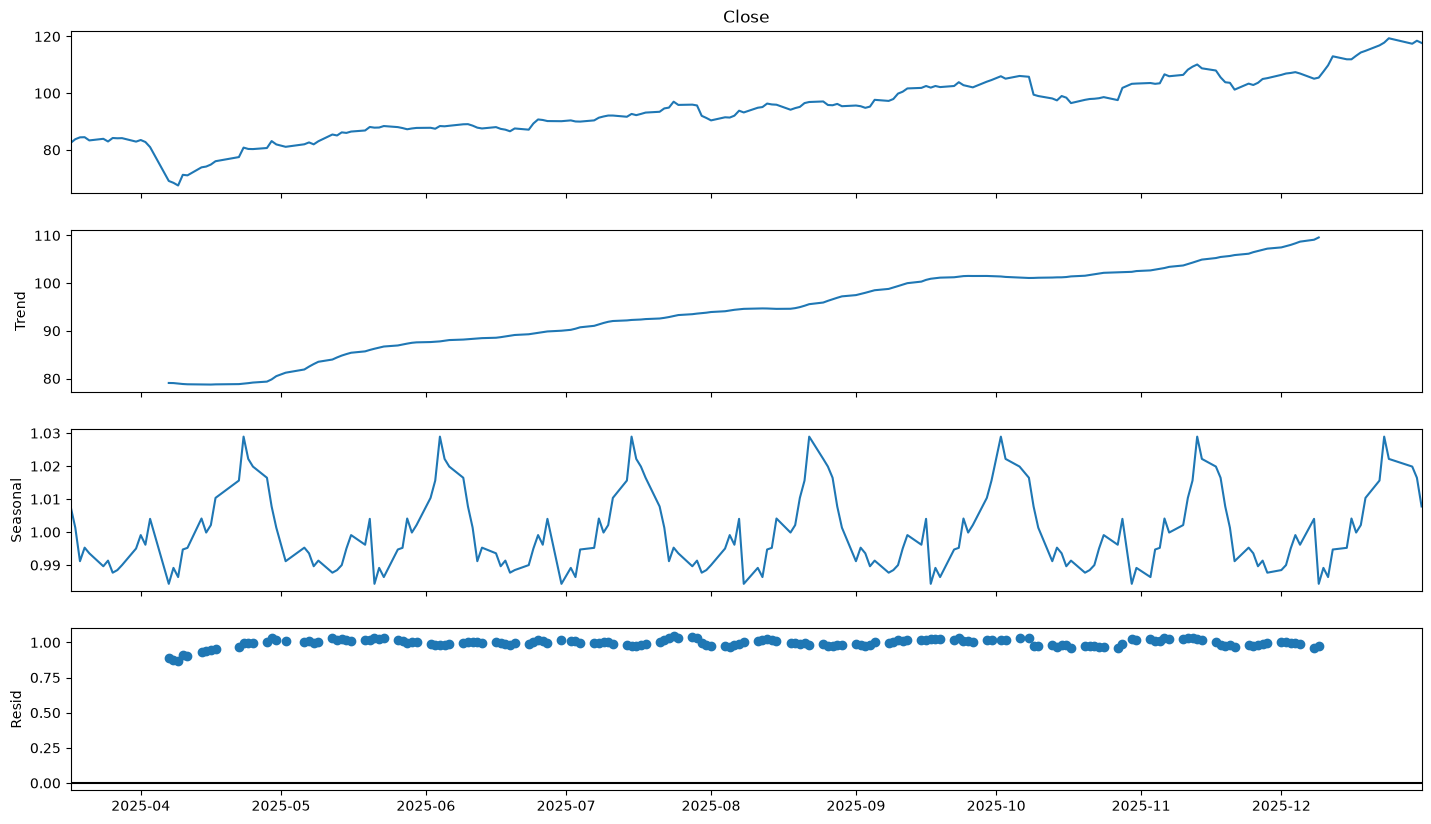

In [19]:
#from statsmodels.tsa.seasonal import seasonal_decompose

#To plot & view the trend and the seasonality
# here set the period to 28 as monthly average 

df_close = df['Close']
result = seasonal_decompose(df_close, model='multiplicative',period=28)
fig = plt.figure()  
fig = result.plot()  
fig.set_size_inches(16, 9)

Text(0.5, 1.0, 'Transformed data')

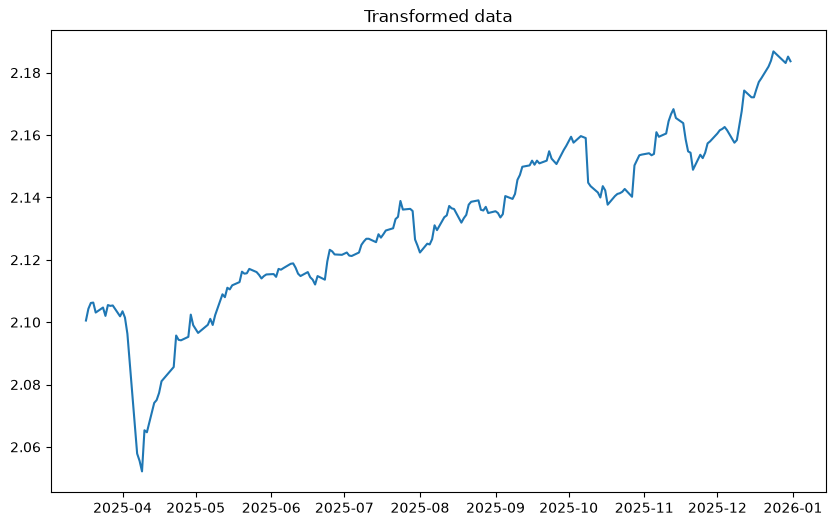

In [20]:
#... To apply log transform to reduce the trends effect while square root transform to flatten 

df_close_log = df_close.apply(np.log)
df_close_tf = df_close_log.apply(np.sqrt)

plt.figure(figsize = (10,6))
plt.plot(df_close_tf)
plt.title('Transformed data')

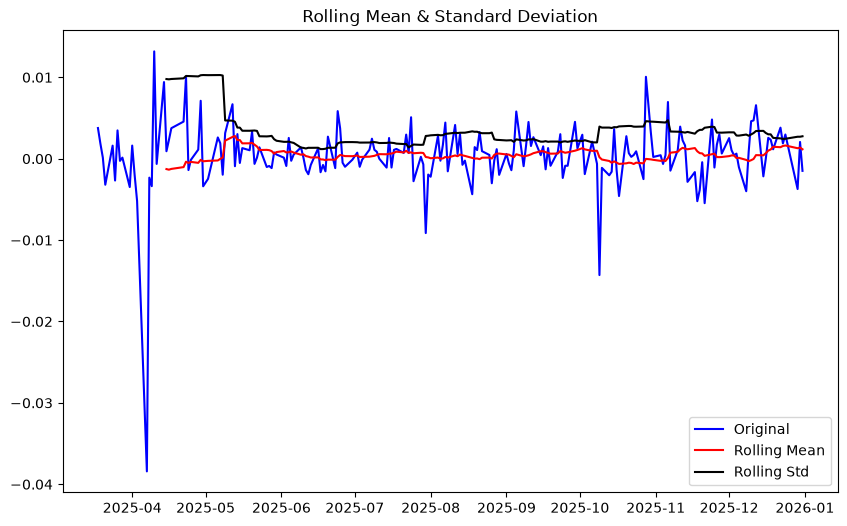

Results of Dickey-Fuller Test:
Test Statistic                -7.733467e+00
p-value                        1.109490e-11
#Lags Used                     1.300000e+01
Number of Observations Used    1.820000e+02
Critical Value (1%)           -3.466800e+00
Critical Value (5%)           -2.877555e+00
Critical Value (10%)          -2.575308e+00
dtype: float64


In [21]:
#... classical methold differenciating to handel with trand and seasonality
df_close_shift = df_close_tf - df_close_tf.shift()

df_close_shift.dropna(inplace=True)
plt.figure(figsize = (10,6))
test_stationarity(df_close_shift)

check p-value

In [22]:
#...MS LSTM
def preprocess_lstm(sequence, n_steps,n_features):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this pattern
        end_ix = i + n_steps
        # check if we are beyond the sequence
        if end_ix >= len(sequence):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
        X.append(seq_x)
        y.append(seq_y)
        
    X = np.array(X)
    y = np.array(y)

    X = X.reshape((X.shape[0], X.shape[1], n_features))
    return X, y

# choose the number of days on which to base our predictions 
#nb_days = 60
n_features = 1

X, y = preprocess_lstm(df_close_shift.to_numpy(), nb_days, n_features)

#Split the data set between the training set and the test set (20%)
#test_days = 135 

X_train, y_train = X[:-test_days], y[:-test_days]
X_test, y_test = X[-test_days:], y[-test_days:]

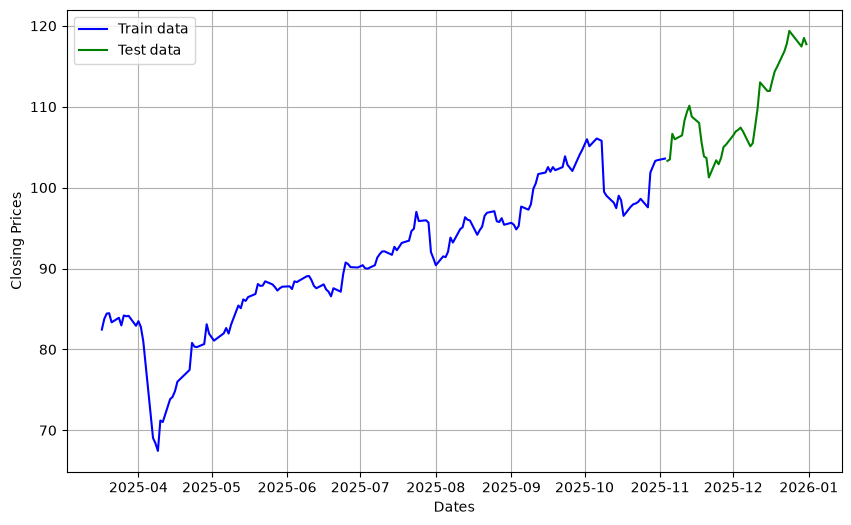

In [23]:
#... Split Data
train_original = df_close.iloc[:-test_days]
test_original = df_close.iloc[-test_days:]

plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(train_original, 'b', label='Train data')
plt.plot(test_original, 'g', label='Test data')
plt.legend()

In [24]:
#... LSTM Vanilla LSTM
def vanilla_LSTM():
    model = Sequential()    
    model.add(LSTM(units=50, input_shape=(nb_days, n_features)))
    model.add(Dense(1))
    return model

#
model = vanilla_LSTM()
model.summary()
model.compile(optimizer='adam', 
              loss='mean_squared_error',
              metrics=[tf.keras.metrics.MeanAbsoluteError()])    

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
#...Train and evaluate model
model.fit(X_train, 
          y_train, 
          epochs=epochsMS, 
          batch_size = batch_sizeMS)

Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 4.1922e-05 - mean_absolute_error: 0.0052
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 4.1904e-05 - mean_absolute_error: 0.0058
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 1.5602e-05 - mean_absolute_error: 0.0032
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 2.7135e-05 - mean_absolute_error: 0.0044
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 1.3676e-05 - mean_absolute_error: 0.0027
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 1.4708e-05 - mean_absolute_error: 0.0030
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 1.3067e-05 - mean_absolute_error: 0.0027
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 9.6131e-06 - mean_absolute_error: 0.0022
Epoch 9/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 1.2058e-05 - mean_absolute_error: 0.0026
Epoch 10/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 9.2056e-06 - mean_absolute_error: 0.0022
Epoch 11/15
3/3 ━━━

In [27]:
#...
# Evaluate the model on the test data using
print("Evaluate on test data")
results = model.evaluate(X_test, y_test, batch_size=32)
print("Test MSE:", results[0])
print("Test MAE:", results[1])

Evaluate on test data
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 9.1331e-06 - mean_absolute_error: 0.0025 
Test MSE: 9.133085768553428e-06
Test MAE: 0.0024560485035181046


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 313ms/step


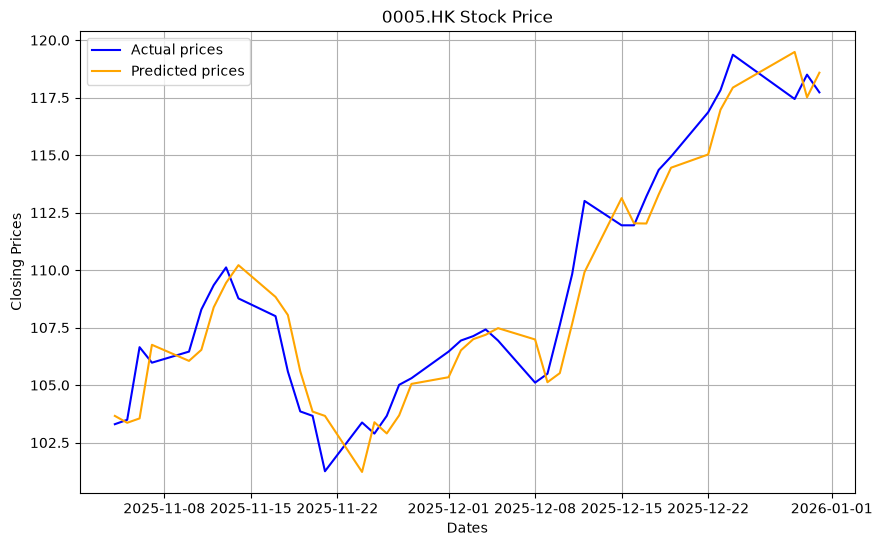

In [28]:
#...
# Prediction
y_pred = model.predict(X_test)

# We create a dataframe from y_pred to have date-time indexes.
pred_data = pd.DataFrame(y_pred[:,0], test_original.index,columns=['Close'])

# Apply inverse transformation from 1.d

# Add the differenciation term
pred_data['Close'] = pred_data['Close'] + df_close_tf.shift().values[-test_days:] 

# Take the square, and the exponent
pred_data = pred_data.apply(np.square)
pred_data = pred_data.apply(np.exp)

# Plot actual prices vs predicted prices 
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(test_original,'b',label='Actual prices')
plt.plot(pred_data, 'orange',label='Predicted prices')
#plt.title(' Stock Price')
plt.title(company + ' Stock Price')

plt.legend()

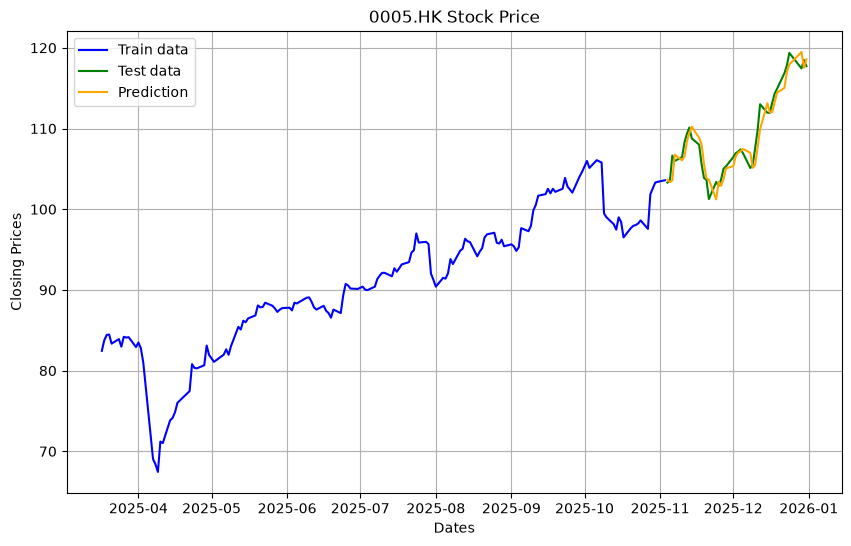

In [29]:
#...
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(train_original, 'b', label='Train data')
plt.plot(test_original, 'g', label='Test data')
plt.plot(pred_data, 'orange', label='Prediction')
plt.title(company + ' Stock Price')
plt.legend()

In [30]:
#...Multiple-Step LSTM
def preprocess_multistep_lstm(sequence, n_steps_in, n_steps_out, features):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the sequence
        if out_end_ix > len(sequence):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix:out_end_ix]
        X.append(seq_x)
        y.append(seq_y)

    X = np.array(X)
    y = np.array(y)

    X = X.reshape((X.shape[0], X.shape[1], n_features))
    
    return X, y

# Number of days into the future we want to predict
#n_steps_out = 30

# choose the number of days on which to base our predictions 
#nb_days = 60

n_features = 1

X, y = preprocess_multistep_lstm(df_close_shift.to_numpy(), nb_days, n_steps_out, n_features)

#
#Split the data set between the training set and the test set (20%)
#test_days = 135 

X_train, y_train = X[:-test_days], y[:-test_days]
X_test, y_test = X[-test_days:], y[-test_days:]

In [31]:
#...
def vanilla_multistep_LSTM():
    model = Sequential()    
    model.add(LSTM(units=50, input_shape=(nb_days, n_features)))
    model.add(Dense(n_steps_out))
    return model

#
model = vanilla_multistep_LSTM()
model.summary()
model.compile(optimizer='adam', 
              loss='mean_squared_error',
              metrics=[tf.keras.metrics.MeanAbsoluteError()])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 30)                  │           1,530 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,930 (46.60 KB)

 Trainable params: 11,930 (46.60 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
#...
model.fit(X_train, 
          y_train, 
          epochs=epochsMS, 
          batch_size = batch_sizeMS)

Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 1.0751e-05 - mean_absolute_error: 0.0024
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 1.1080e-05 - mean_absolute_error: 0.0025
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 9.0654e-06 - mean_absolute_error: 0.0022
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 9.6079e-06 - mean_absolute_error: 0.0023
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 9.0133e-06 - mean_absolute_error: 0.0022
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 8.9165e-06 - mean_absolute_error: 0.0021
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 8.9318e-06 - mean_absolute_error: 0.0021
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 8.7101e-06 - mean_absolute_error: 0.0021
Epoch 9/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 9.0031e-06 - mean_absolute_error: 0.0022
Epoch 10/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 8.5954e-06 - mean_absolute_error: 0.0021
Epoch 11/15
3/3 ━━━

In [33]:
#...
# Evaluate the model on the test set
print("Evaluate on test data")
results = model.evaluate(X_test, y_test, batch_size=32)

print("Test MSE:", results[0])
print("Test MAE:", results[1])

Evaluate on test data
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 1.2826e-05 - mean_absolute_error: 0.0026
Test MSE: 1.2826270904042758e-05
Test MAE: 0.0026223082095384598


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step


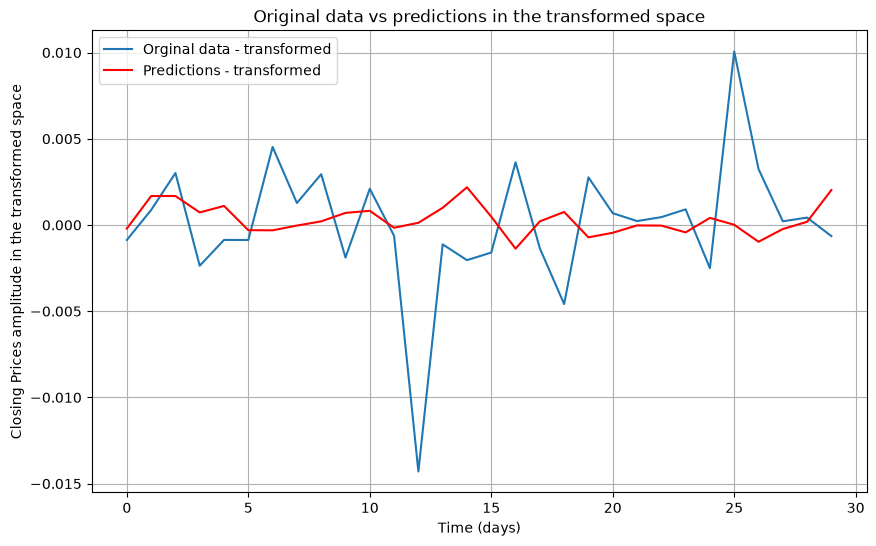

In [34]:
#...
# Prediction
y_pred = model.predict(X_test)

# the_day is the day from which we will study the n_steps_out-th dayS of prediction into 
# the future. Note: The first day start at index 0
the_day = 0
y_pred_days = y_pred[the_day,:]

plt.figure(figsize=(10,6))
plt.grid(True)
plt.plot(y_test[the_day,:],label='Orginal data - transformed')
plt.plot(y_pred_days, color='red',label='Predictions - transformed')
plt.xlabel('Time (days)')
plt.ylabel('Closing Prices amplitude in the transformed space')
plt.title('Original data vs predictions in the transformed space')
plt.legend()

In [35]:
#...
# Apply inverse transformations from 3.a

# Add the differenciation term
pred_diff_cumsum = y_pred_days.cumsum()

base_number = df_close_tf.values[-test_days+the_day+nb_days-1]
idx = test_original.iloc[the_day:the_day+n_steps_out].index

pred_tf = pd.Series(base_number, index=idx)
pred_tf = pred_tf.add(pred_diff_cumsum,fill_value=0)

print(pred_tf)

Date
2025-11-04    2.073906
2025-11-05    2.075585
2025-11-06    2.077267
2025-11-07    2.077995
2025-11-10    2.079101
2025-11-11    2.078802
2025-11-12    2.078493
2025-11-13    2.078459
2025-11-14    2.078670
2025-11-17    2.079374
2025-11-18    2.080195
2025-11-19    2.080034
2025-11-20    2.080162
2025-11-21    2.081159
2025-11-24    2.083345
2025-11-25    2.083828
2025-11-26    2.082455
2025-11-27    2.082666
2025-11-28    2.083422
2025-12-01    2.082705
2025-12-02    2.082254
2025-12-03    2.082229
2025-12-04    2.082194
2025-12-05    2.081766
2025-12-08    2.082178
2025-12-09    2.082192
2025-12-10    2.081219
2025-12-11    2.080984
2025-12-12    2.081169
2025-12-15    2.083197
dtype: float64


In [36]:
#...
# Take the square, and the exponent
pred_log = pred_tf.apply(np.square)
pred = pred_log.apply(np.exp)
print(pred)

Date
2025-11-04    73.779959
2025-11-05    74.295836
2025-11-06    74.816364
2025-11-07    75.043058
2025-11-10    75.389106
2025-11-11    75.295171
2025-11-12    75.198506
2025-11-13    75.187951
2025-11-14    75.254140
2025-11-17    75.474551
2025-11-18    75.732850
2025-11-19    75.682175
2025-11-20    75.722290
2025-11-21    76.037200
2025-11-24    76.732644
2025-11-25    76.887248
2025-11-26    76.448621
2025-11-27    76.515702
2025-11-28    76.757242
2025-12-01    76.528391
2025-12-02    76.384721
2025-12-03    76.376748
2025-12-04    76.365651
2025-12-05    76.229650
2025-12-08    76.360470
2025-12-09    76.364876
2025-12-10    76.056157
2025-12-11    75.981998
2025-12-12    76.040309
2025-12-15    76.685396
dtype: float64


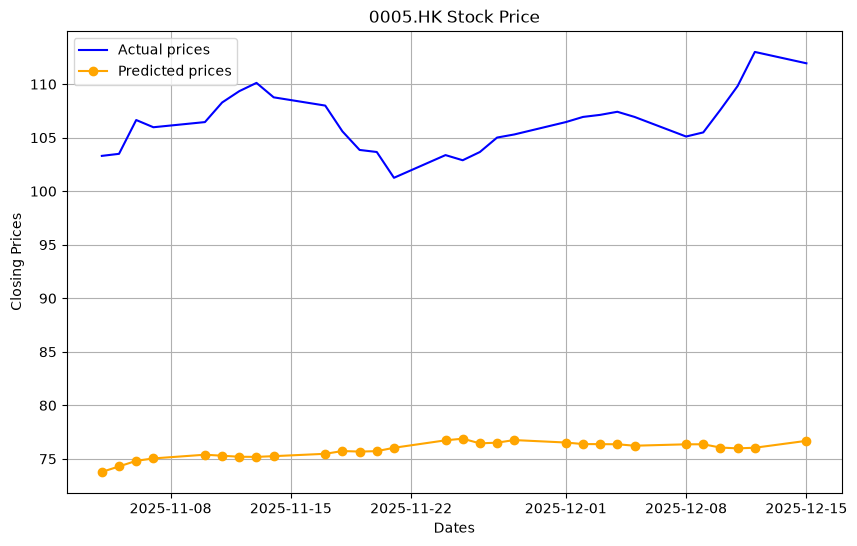

In [37]:
#...
# Plot actual prices vs predicted prices 
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(test_original.iloc[max(0,the_day-30):the_day+n_steps_out],'b',label='Actual prices')
plt.plot(pred, '-o',color='orange',label='Predicted prices')
plt.title(company + ' Stock Price')

plt.legend()

In [38]:
#import pandas as pd
#import numpy as np
#import matplotlib.pyplot as plt
#import seaborn as sns
from sklearn.metrics import r2_score
import statsmodels.api as sm

# 1. Extract the exact actual prices that align with the prediction period
# Based on your plot, 'pred' starts at 'the_day' and goes forward for 'n_steps_out' steps.
actual_for_pred_period = test_original.iloc[the_day : the_day + n_steps_out]

# 2. Ensure both are flattened 1D arrays/Series with no missing values
y_true = actual_for_pred_period.values.flatten()
y_pred = pred.flatten() if hasattr(pred, 'flatten') else pred

X = sm.add_constant(y_true)

#fit linear regression model
model = sm.OLS(y_pred, X).fit()

#view model summary
summary = model.summary()
print(summary)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.036
Method:                 Least Squares   F-statistic:                  0.001940
Date:                Sat, 26 Sep 2026   Prob (F-statistic):              0.965
Time:                        20:44:26   Log-Likelihood:                -33.712
No. Observations:                  30   AIC:                             71.42
Df Residuals:                      28   BIC:                             74.23
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         75.6095      5.555     13.610      0.0

In [39]:
#import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Replace these arrays with your actual test data and model predictions
# Example: y_true (actual market prices), y_pred (your LSTM or ARIMA predictions)
#y_true = np.array([100.0, 102.5, 101.2, 105.0, 107.8])
#y_pred = np.array([101.2, 101.0, 102.0, 104.5, 109.1])

# 2. Calculate Standard Regression Metrics
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)  # Alternative: mean_squared_error(y_true, y_pred, squared=False)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

# 3. Calculate Directional Accuracy (Crucial for price trends)
# Compares if the predicted direction (up/down) matches the actual direction
actual_direction = np.diff(y_true) > 0
predicted_direction = np.diff(y_pred) > 0
directional_accuracy = np.mean(actual_direction == predicted_direction) * 100

# 4. Print Evaluation Results
print("--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE):      {mae:.4f}")
print(f"Mean Squared Error (MSE):       {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Pct Error (MAPE): {mape:.2f}%")
print(f"R² Score (Goodness of Fit):     {r2:.4f}")
print(f"Directional Accuracy (DA):      {directional_accuracy:.2f}%")


--- Model Evaluation Metrics ---
Mean Absolute Error (MAE):      30.5747
Mean Squared Error (MSE):       942.5989
Root Mean Squared Error (RMSE): 30.7018
Mean Absolute Pct Error (MAPE): 28.68%
R² Score (Goodness of Fit):     -128.6956
Directional Accuracy (DA):      34.48%


In [47]:
# Follow from ADF Test if series is stationary
scaler = MinMaxScaler()
df['Close'] = scaler.fit_transform(df[['Close']])

In [48]:
# Train and Verify Split (80:20 Ratio)
#from sklearn.model_selection import train_test_split

def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back):
        dataX.append(dataset[i:(i + look_back)])
        dataY.append(dataset[i + look_back])
    return np.array(dataX), np.array(dataY)

close_values = df['Close'].values 

X, Y = create_dataset(close_values, look_back=30)

trainX, testX, trainY, testY = train_test_split(X, Y, test_size=0.2, shuffle=False)


In [49]:
# Data for LSTM 
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))
testX = np.reshape(testX, (testX.shape[0], testX.shape[1], 1))

In [43]:
#1 LSTM ***SKIP
model = Sequential()
model.add(LSTM(units=50, input_shape=(30, 1)))
model.add(Dense(units=1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.summary()
model.fit(trainX, trainY, epochs=30, batch_size=32)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.2327
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0837
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0080
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0240
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0038
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0070
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0062
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0027
Epoch 9/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0033
Epoch 10/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0034
Epoch 11/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0024
Epoch 12/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0028
Epoch 13/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0026
Epoch 14/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0022
Epoch 15/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0024
Epoch 16/30
5/5 ━━━━━━━━━━━━━━━━━━

#
LSTM(50 units) → Captures long-term dependencies

Dropout(0.2) → Prevents overfitting

Dense Layers → Produces final prediction

In [50]:
#2 LSTM
#from tensorflow.keras.models import Sequential  
#from tensorflow.keras.layers import LSTM, Dense, Dropout  

model = Sequential([  
    LSTM(units=50, return_sequences=True, input_shape=(trainX.shape[1], 1)),  
    Dropout(0.2),  
    LSTM(units=50, return_sequences=False),  
    Dropout(0.2),  
    Dense(units=25),  
    Dense(units=1)  
])  

model.compile(optimizer='adam', loss='mean_squared_error')

model.fit(trainX, trainY, epochs=30, batch_size=32)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 0.1173
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0355
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0092
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0168
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0080
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0074
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0066
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0076
Epoch 9/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0077
Epoch 10/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0052
Epoch 11/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0048
Epoch 12/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0052
Epoch 13/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0056
Epoch 14/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0058
Epoch 15/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0052
Epoch 16/30
5/5 ━━━━━━━━━━━━━━━━━━

In [51]:
# Prediction & Result
testPredict = model.predict(testX)
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform(testY.reshape(-1, 1))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 405ms/step


In [52]:
#from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(testY, testPredict))
print(f"Root Mean Squared Error (RMSE): {rmse}")

Root Mean Squared Error (RMSE): 0.07829951388945676


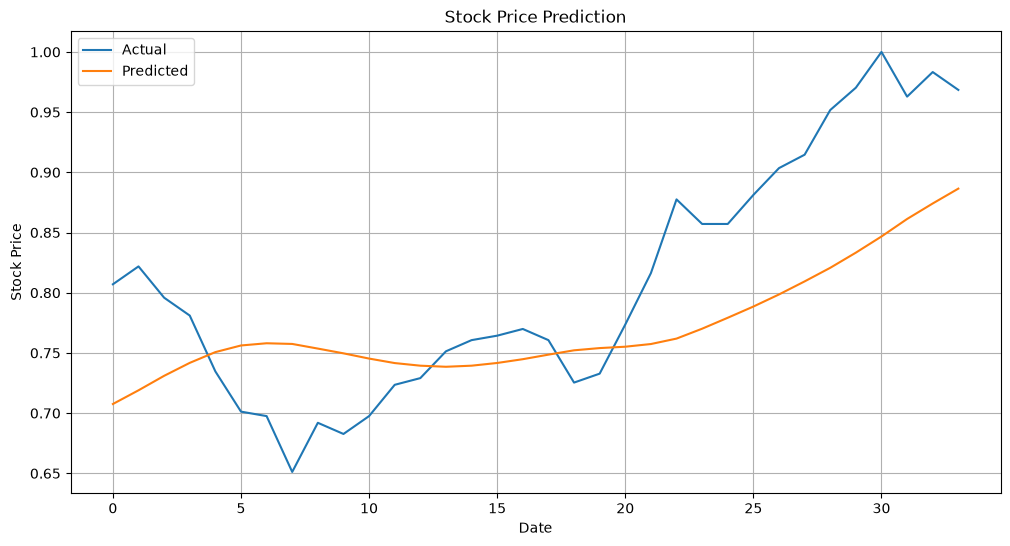

In [53]:
#2
plt.figure(figsize=(12, 6))
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title("Stock Price Prediction")
plt.plot(testY, label='Actual')
plt.plot(testPredict, label='Predicted')
plt.grid(True)
plt.legend()
plt.show()

For this study, we will focus on the closing price, as it represents the final market sentiment for each trading day.